## Kullanılan Kütüphaneler

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Veri Ön İşleme

### Eğitim verilerini ön işleme

In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\archive-dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### Doğrulama Verilerini Ön İşleme

In [7]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\archive-dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


#### Aşırı hata kaybını önlemek için 
1. Küçük bir öğrenme oranı seçin (varsayılan 0,001, burada 0,0001 aldık).
2. Yetersiz uyum olasılığı olabilir, bu nedenle nöron sayısını artırın.
3. Görüntülerden daha fazla özellik çıkarmak için daha fazla Evrişim Katmanı ekleyin; modelin ilgili özelliği yakalayamaması veya özellik eksikliğinden dolayı modelin kafasının karışması olasılığı olabilir, bu nedenle daha fazla özellik ile besleyin.

## Model Oluşturma

In [10]:
cnn = tf.keras.models.Sequential() 

### Evrişim Katmanı Oluşturma 

In [12]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [15]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [16]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [17]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [18]:
cnn.add(tf.keras.layers.Flatten())

In [19]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [ ]:
cnn.add(tf.keras.layers.Dropout(0.4)) 

In [ ]:

cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

### Modeli derleme ve Eğitimi 

In [23]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3119s 1s/step - accuracy: 0.3758 - loss: 2.2410 - val_accuracy: 0.8074 - val_loss: 0.5920
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3091s 1s/step - accuracy: 0.8330 - loss: 0.5252 - val_accuracy: 0.9016 - val_loss: 0.3028
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3083s 1s/step - accuracy: 0.9051 - loss: 0.2971 - val_accuracy: 0.9354 - val_loss: 0.1928
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3069s 1s/step - accuracy: 0.9335 - loss: 0.2009 - val_accuracy: 0.9294 - val_loss: 0.2197
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3264s 1s/step - accuracy: 0.9533 - loss: 0.1398 - val_accuracy: 0.9391 - val_loss: 0.1858
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3240s 1s/step - accuracy: 0.9658 - loss: 0.1058 - val_accuracy: 0.9608 - val_loss: 0.1329
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3319s 2s/step - accuracy: 0.9690 - loss: 0.0948 - val_accuracy: 0.9597 - val_loss: 0.1326
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3131s 1s/step - accuracy: 0.9751 -

## Modeli değerlendirme

In [27]:
#Eğitim seti doğruluğu
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1386s 631ms/step - accuracy: 0.9902 - loss: 0.0307
Training accuracy: 0.9912084937095642


In [28]:
#Doğrulama seti doğruluğu
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 241s 438ms/step - accuracy: 0.9643 - loss: 0.1245
Validation accuracy: 0.965114951133728


### Modeli kaydetme

In [30]:
cnn.save('trained_plant_disease_model.keras')

In [31]:
training_history.history #Return Dictionary of history

{'accuracy': [0.5811508893966675,
  0.855053722858429,
  0.9124119877815247,
  0.9366811513900757,
  0.9547905325889587,
  0.9653602838516235,
  0.9706664681434631,
  0.9768973588943481,
  0.9782061576843262,
  0.9830286502838135],
 'loss': [1.4343247413635254,
  0.4553751051425934,
  0.27310997247695923,
  0.19161924719810486,
  0.13737916946411133,
  0.106007881462574,
  0.08888249099254608,
  0.07106292247772217,
  0.06611499190330505,
  0.05363578721880913],
 'val_accuracy': [0.8073639869689941,
  0.9016048312187195,
  0.9353516697883606,
  0.9293763041496277,
  0.9391076564788818,
  0.9608467817306519,
  0.9597086310386658,
  0.9454814195632935,
  0.9605622291564941,
  0.965114951133728],
 'val_loss': [0.5919849872589111,
  0.30275124311447144,
  0.19276002049446106,
  0.21973012387752533,
  0.18584249913692474,
  0.1328972727060318,
  0.13260531425476074,
  0.18880407512187958,
  0.1351580023765564,
  0.1265064775943756]}

In [32]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [33]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Değerlendirmeyi görselleştirme

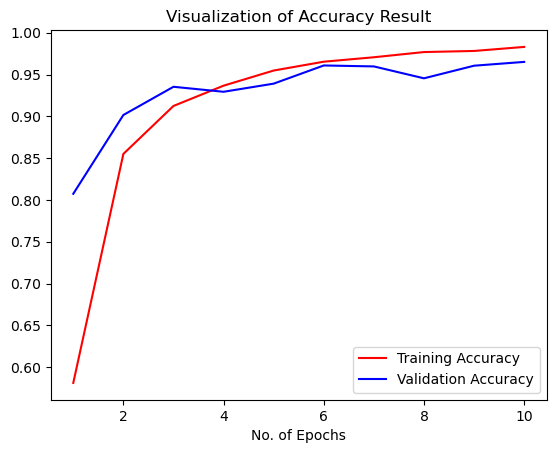

In [35]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Model değerlendirme için diğer ölçümler

In [37]:
class_name = validation_set.class_names

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\archive-dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [41]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 392s 22ms/step


In [43]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [ ]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [47]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [50]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [52]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.98      0.95       504
                                 Apple___Black_rot       0.98      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.93      0.96       440
                                   Apple___healthy       0.95      0.98      0.96       502
                               Blueberry___healthy       0.97      0.99      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.96      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.82      0.89       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.98      0.

### Karışıklık Matrisi Görselleştirme

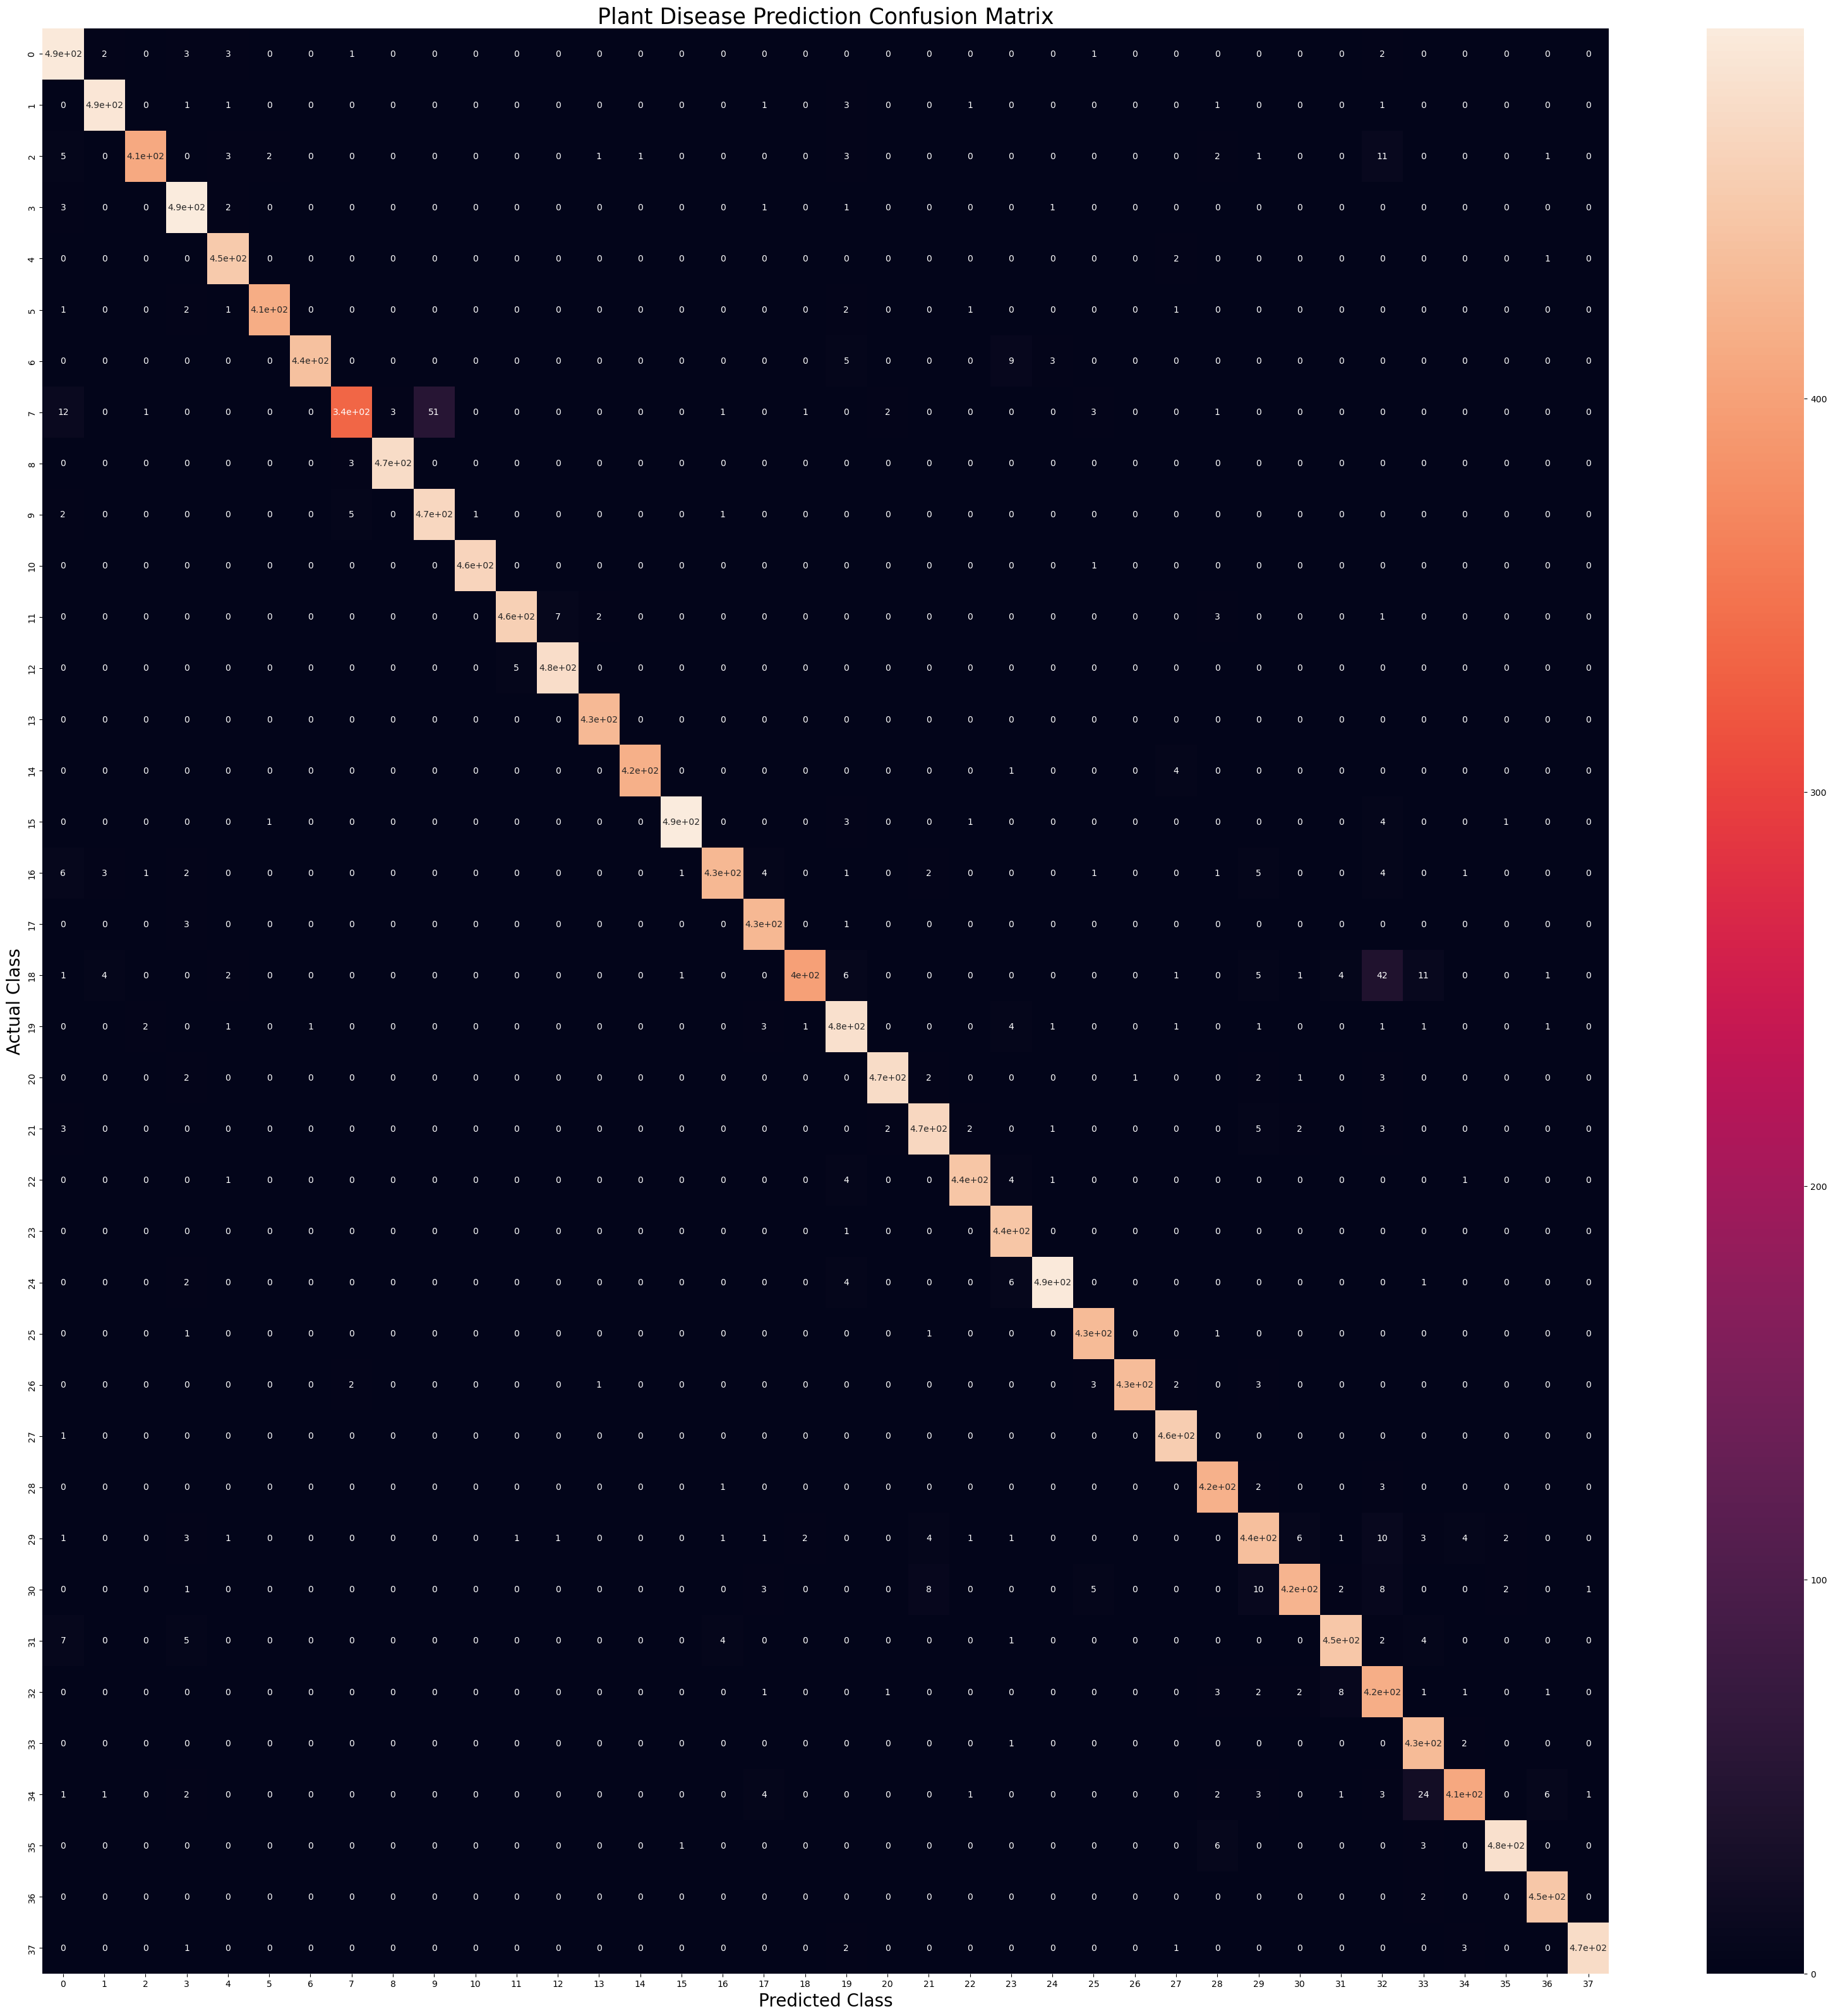

In [55]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

In [57]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,528,288 (89.75 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,685,526 (59.84 MB)

In [59]:
cnn.save('bitkilerde-hastalık-tespiti.keras');